In [1]:
import time
t1 = time.time()

import math
import os
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam , SGD , Adagrad
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler, EarlyStopping, CSVLogger, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras import regularizers , initializers
from sklearn.metrics import confusion_matrix
import tensorflow.keras.backend as K
from sklearn import metrics
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

gpus = tf.config.experimental.list_physical_devices("GPU")
tf.config.set_visible_devices(gpus[0], "GPU")

### set seed ###
keras.utils.set_random_seed(2330)
tf.config.experimental.enable_op_determinism()

2026-03-19 07:47:01.639590: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
##### load data #####

hhvv_HLdata_path = "/root/data/mucollider/two_boosted/scan_kappa3_hhvv_HL.h5"
hhvv_HLdata_file = h5py.File(hhvv_HLdata_path, 'r')
print(hhvv_HLdata_file.keys())

hhvv_LLdata_path = "/root/data/mucollider/two_boosted/scan_kappa3_hhvv_LL.h5"
hhvv_LLdata_file = h5py.File(hhvv_LLdata_path, 'r')
print(hhvv_LLdata_file.keys())

hhmumu_HLdata_path = "/root/data/mucollider/two_boosted/scan_kappa3_hhmumu_HL.h5"
hhmumu_HLdata_file = h5py.File(hhmumu_HLdata_path, 'r')
print(hhmumu_HLdata_file.keys())

hhmumu_LLdata_path = "/root/data/mucollider/two_boosted/scan_kappa3_hhmumu_LL.h5"
hhmumu_LLdata_file = h5py.File(hhmumu_LLdata_path, 'r')
print(hhmumu_LLdata_file.keys())

<KeysViewHDF5 ['BTag_leading', 'BTag_subleading', 'H_0', 'H_1', 'LB_1', 'M_JJ', 'S_0', 'S_1', 'X_HH', 'dEta_JJ', 'm_J_leading', 'm_J_subleading', 'missET', 'pT_JJ', 'pt_J_leading', 'pt_J_subleading', 'target_kappa_3']>
<KeysViewHDF5 ['particle_info']>
<KeysViewHDF5 ['BTag_leading', 'BTag_subleading', 'H_0', 'H_1', 'LB_1', 'M_JJ', 'S_0', 'S_1', 'X_HH', 'dEta_JJ', 'm_J_leading', 'm_J_subleading', 'missET', 'pT_JJ', 'pt_J_leading', 'pt_J_subleading', 'target_kappa_3']>
<KeysViewHDF5 ['particle_info']>


In [3]:
##### include data #####

HLfeatures = ['BTag_leading', 'BTag_subleading', 'H_0', 'H_1', 'LB_1', 'M_JJ', 'S_0', 'S_1', 'X_HH', 'dEta_JJ', 'm_J_leading', 'm_J_subleading', 'missET', 'pT_JJ', 'pt_J_leading', 'pt_J_subleading']
LLfeatures = ['particle_info']

##### select BTag work point at WP70 (BitNumber 1) #####

hhvv_BTag_leading = ((hhvv_HLdata_file['BTag_leading'][:])&2)
hhvv_BTag_subleading = ((hhvv_HLdata_file['BTag_subleading'][:])&2)

hhmumu_BTag_leading = ((hhmumu_HLdata_file['BTag_leading'][:])&2)
hhmumu_BTag_subleading = ((hhmumu_HLdata_file['BTag_subleading'][:])&2)

##### include other high level features data #####

hhvv_HLdata = []
for feature in HLfeatures:
    if feature=='BTag_leading': hhvv_HLdata.append(hhvv_BTag_leading)
    elif feature=='BTag_subleading': hhvv_HLdata.append(hhvv_BTag_subleading)
    else: hhvv_HLdata.append(hhvv_HLdata_file[feature][:])
hhvv_HLdata = np.array(hhvv_HLdata).T
print('shape of high level data:', hhvv_HLdata.shape)

hhvv_LLdata = hhvv_LLdata_file['particle_info'][:]
print('shape of low level data:', hhvv_LLdata.shape)

hhmumu_HLdata = []
for feature in HLfeatures:
    if feature=='BTag_leading': hhmumu_HLdata.append(hhmumu_BTag_leading)
    elif feature=='BTag_subleading': hhmumu_HLdata.append(hhmumu_BTag_subleading)
    else: hhmumu_HLdata.append(hhmumu_HLdata_file[feature][:])
hhmumu_HLdata = np.array(hhmumu_HLdata).T
print('shape of high level data:', hhmumu_HLdata.shape)

hhmumu_LLdata = hhmumu_LLdata_file['particle_info'][:]
print('shape of low level data:', hhmumu_LLdata.shape)

shape of high level data: (321016, 16)
shape of low level data: (321016, 160)
shape of high level data: (314674, 16)
shape of low level data: (314674, 160)


In [4]:
##### define the event information #####

BR_hbb = 0.5824
Luminosity = 1000   ### unit: fb^-1
simulation_num = 100000
kappa3 = [0.2, 0.4, 0.6, 0.8, 0.9, 1.0, 1.1, 1.2, 1.4, 1.6, 1.8]

hhvv_Xsection_NoDecay = [1.23322e-01, 1.016366e-01, 8.33476424e-02, 6.81961e-02, 6.2211286e-02, 5.648398e-02, 5.187586e-02, 4.801255e-02, 4.246736e-02, 4.038406e-02, 4.1308219e-02]     ### hhvv unit: fb
hhvv_Xsection = [hhvv_Xsection_NoDecay[i]*BR_hbb*BR_hbb for i in range(11)]
hhvv_event_num = [31536, 31077, 30923, 30485, 30011, 29716, 29039, 28528, 27438, 26495, 25768]

hhmumu_Xsection_NoDecay = [1.068573e-2, 8.89267e-3, 7.29573e-3, 5.892737e-3, 5.2836183e-3, 4.68848e-3, 4.1895e-3, 3.7137245e-3, 2.9218193e-3, 2.3228e-3, 1.9414667e-3]     ### hhmumu unit: fb
hhmumu_Xsection = [hhmumu_Xsection_NoDecay[i]*BR_hbb*BR_hbb for i in range(11)]
hhmumu_event_num = [30469, 30020, 29858, 29497, 29190, 28845, 28653, 28343, 27442, 26613, 25744]

In [5]:
##### load the model #####

model = models.load_model("/root/data/mucollider/two_boosted/model_mucollider_v2.h5")

2026-03-19 07:47:04.495421: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1639] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46696 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:01:00.0, compute capability: 8.6


In [6]:
### model test ###

hhvv_HLtest = []
hhvv_LLtest = []
hhvv_prediction = []

hhmumu_HLtest = []
hhmumu_LLtest = []
hhmumu_prediction = []

count = 0
for kappa3_val in kappa3:
    hhvv_HLtest.append(hhvv_HLdata[count:count+hhvv_event_num[kappa3.index(kappa3_val)]])
    hhvv_LLtest.append(hhvv_LLdata[count:count+hhvv_event_num[kappa3.index(kappa3_val)]])
    hhvv_prediction.append(model.predict([hhvv_HLtest[-1], hhvv_LLtest[-1]]))
    count += hhvv_event_num[kappa3.index(kappa3_val)]

count = 0
for kappa3_val in kappa3:
    hhmumu_HLtest.append(hhmumu_HLdata[count:count+hhmumu_event_num[kappa3.index(kappa3_val)]])
    hhmumu_LLtest.append(hhmumu_LLdata[count:count+hhmumu_event_num[kappa3.index(kappa3_val)]])
    hhmumu_prediction.append(model.predict([hhmumu_HLtest[-1], hhmumu_LLtest[-1]]))
    count += hhmumu_event_num[kappa3.index(kappa3_val)]

 82/986 [=>............................] - ETA: 1s

2026-03-19 07:47:06.126156: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:606] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


805/805 [==============================] - 1s 2ms/step


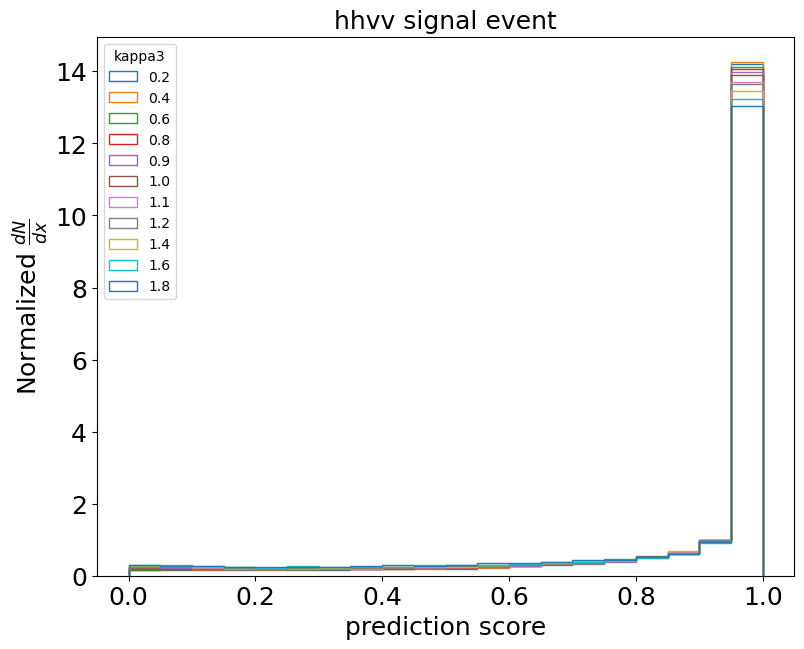

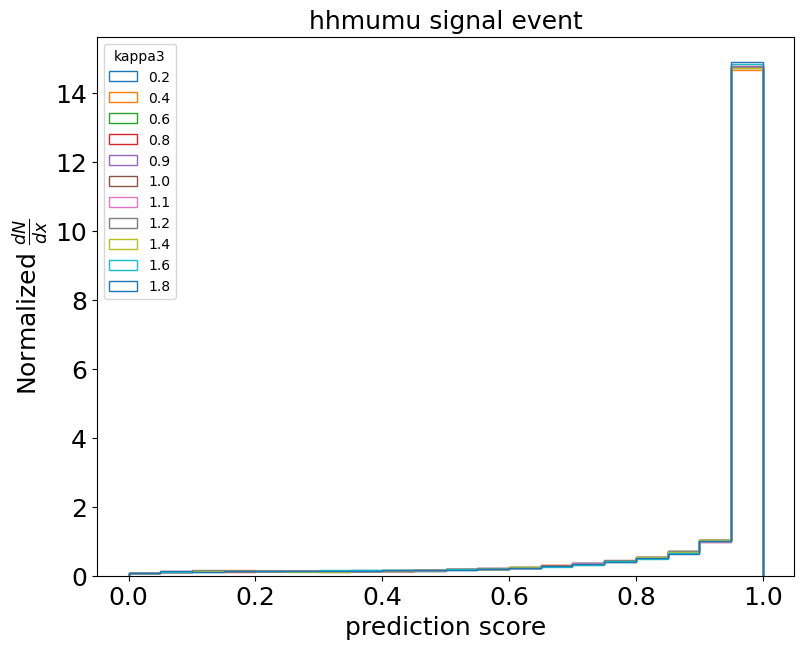

In [7]:
##### plot the prediction histogram #####

plt.figure(1, figsize=(9,7))
bins = np.linspace(0,1,21)
for kappa3_val in kappa3:
    plt.hist(hhvv_prediction[kappa3.index(kappa3_val)], bins=bins, label=kappa3_val, histtype='step', density=True)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlabel(r"prediction score", fontsize=18)
plt.ylabel(r"Normalized $\frac{dN}{dx}$", fontsize=18)
plt.title("hhvv signal event", fontsize=18)
plt.legend(loc='best', title='kappa3')
plt.show()

plt.figure(1, figsize=(9,7))
bins = np.linspace(0,1,21)
for kappa3_val in kappa3:
    plt.hist(hhmumu_prediction[kappa3.index(kappa3_val)], bins=bins, label=kappa3_val, histtype='step', density=True)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlabel(r"prediction score", fontsize=18)
plt.ylabel(r"Normalized $\frac{dN}{dx}$", fontsize=18)
plt.title("hhmumu signal event", fontsize=18)
plt.legend(loc='best', title='kappa3')
plt.show()

In [8]:
##### calculate the selection rate and significance #####

score_cut = 0.95

print("hhvv event:")
hhvv_num_afterML = []
for kappa3_val in kappa3:
    hhvv_num_afterML.append(sum(hhvv_prediction[kappa3.index(kappa3_val)].flatten()>score_cut))
    print("kappa3 value:", kappa3_val, 
          ", ML Selection rate: {:^4.4f}".format(hhvv_num_afterML[kappa3.index(kappa3_val)]/hhvv_event_num[kappa3.index(kappa3_val)]), 
          ", Full selection rate: {:^4.4f}".format(hhvv_num_afterML[kappa3.index(kappa3_val)]/simulation_num))

print("\nhhmumu event:")
hhmumu_num_afterML = []
for kappa3_val in kappa3:
    hhmumu_num_afterML.append(sum(hhmumu_prediction[kappa3.index(kappa3_val)].flatten()>score_cut))
    print("kappa3 value:", kappa3_val, 
          ", ML Selection rate: {:^4.4f}".format(hhmumu_num_afterML[kappa3.index(kappa3_val)]/hhmumu_event_num[kappa3.index(kappa3_val)]), 
          ", Full selection rate: {:^4.4f}".format(hhmumu_num_afterML[kappa3.index(kappa3_val)]/simulation_num))

b = 2.4608272728319998   ### different from the score cut
s = []
significance = []
m2lnLambda = []
for kappa3_val in kappa3:
    tmp_s = hhvv_Xsection[kappa3.index(kappa3_val)]*Luminosity*(hhvv_num_afterML[kappa3.index(kappa3_val)]/simulation_num) 
    + hhmumu_Xsection[kappa3.index(kappa3_val)]*Luminosity*(hhmumu_num_afterML[kappa3.index(kappa3_val)]/simulation_num)
    s.append(tmp_s)
    significance.append(np.sqrt(2*((tmp_s+b)*np.log(1+tmp_s/b)-tmp_s)))
    m2lnLambda.append(2*((tmp_s+b)*np.log(1+tmp_s/b)-tmp_s))

print(s)
print(significance)
print(m2lnLambda)

hhvv event:
kappa3 value: 0.2 , ML Selection rate: 0.7095 , Full selection rate: 0.2238
kappa3 value: 0.4 , ML Selection rate: 0.7124 , Full selection rate: 0.2214
kappa3 value: 0.6 , ML Selection rate: 0.7055 , Full selection rate: 0.2182
kappa3 value: 0.8 , ML Selection rate: 0.7031 , Full selection rate: 0.2143
kappa3 value: 0.9 , ML Selection rate: 0.6989 , Full selection rate: 0.2098
kappa3 value: 1.0 , ML Selection rate: 0.6950 , Full selection rate: 0.2065
kappa3 value: 1.1 , ML Selection rate: 0.6853 , Full selection rate: 0.1990
kappa3 value: 1.2 , ML Selection rate: 0.6818 , Full selection rate: 0.1945
kappa3 value: 1.4 , ML Selection rate: 0.6722 , Full selection rate: 0.1844
kappa3 value: 1.6 , ML Selection rate: 0.6615 , Full selection rate: 0.1753
kappa3 value: 1.8 , ML Selection rate: 0.6513 , Full selection rate: 0.1678

hhmumu event:
kappa3 value: 0.2 , ML Selection rate: 0.7376 , Full selection rate: 0.2248
kappa3 value: 0.4 , ML Selection rate: 0.7340 , Full selectio

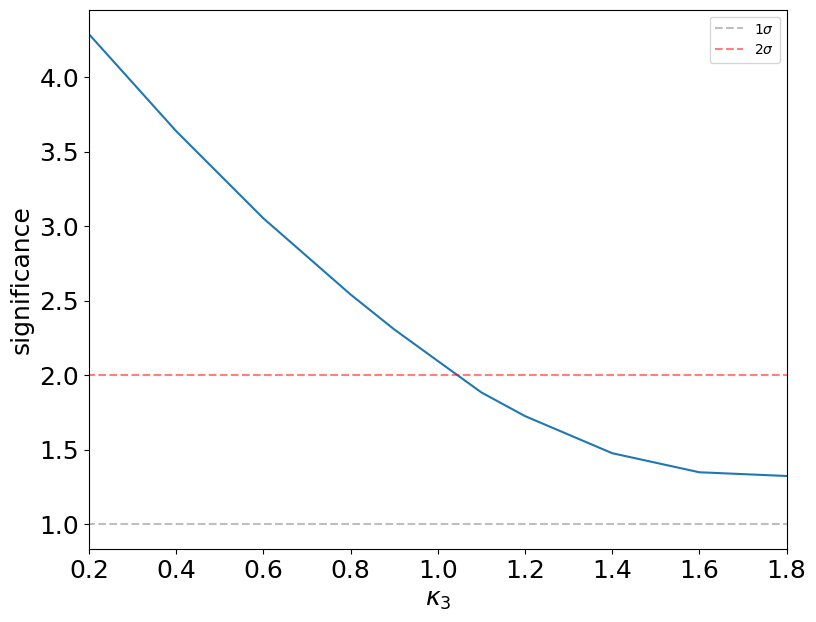

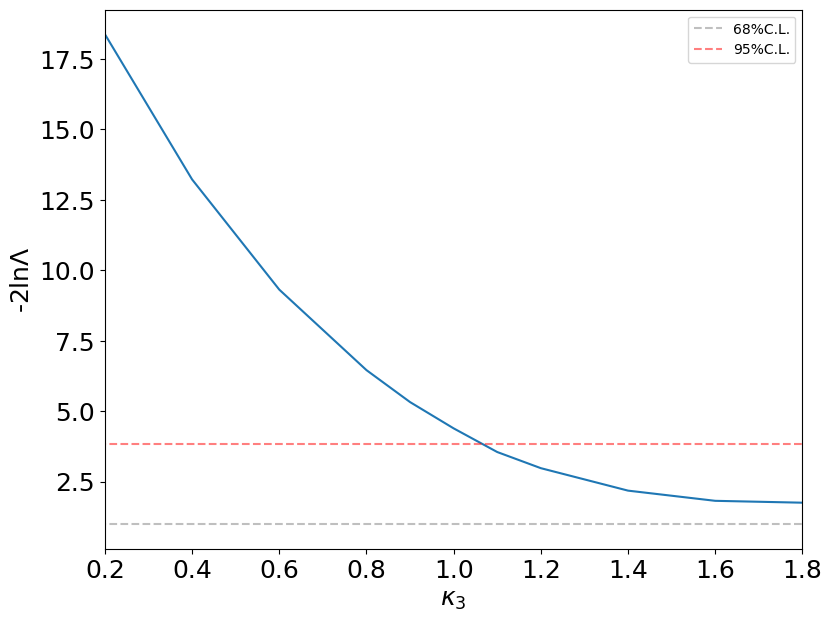

In [10]:
plt.figure(1, figsize=(9,7))
plt.plot(kappa3, significance)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlabel(r"$\kappa_3$", fontsize=18)
plt.ylabel(r"significance", fontsize=18)
plt.xlim(0.2,1.8)
plt.hlines(1, -10, 10, color='gray', alpha=0.5, linestyle="--", label=r"1$\sigma$")
plt.hlines(2, -10, 10, color='red', alpha=0.5, linestyle="--", label=r"2$\sigma$")
plt.legend()
plt.show()

plt.figure(1, figsize=(9,7))
plt.plot(kappa3, m2lnLambda)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlabel(r"$\kappa_3$", fontsize=18)
plt.ylabel(r"-2ln$\Lambda$", fontsize=18)
plt.hlines(0.988036, -10, 10, color='gray', alpha=0.5, linestyle="--", label=r"68%C.L.")
plt.hlines(3.8416, -10, 10, color='red', alpha=0.5, linestyle="--", label=r"95%C.L.")
plt.legend()
plt.xlim(0.2,1.8)
plt.show()